# Comparison plots from pooled_path_comparison.csv

Reads the comparison table. Does not retrain.

**1-day** is next-day error only (`lead_1`). **7 / 14 / 30** are pooled-path scores (the whole 1...H forecast, not day H alone). Plotting them on one x-axis is still useful. They are not the same kind of score. LSTM and GRU have no 1-day row.

Lower is better for MAE, RMSE, MSE, MAPE. Higher is better for R². MBE is signed bias. 0 means unbiased. Positive means the model runs high.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path(".")
df = pd.read_csv(HERE / "pooled_path_comparison.csv")

PREFERRED = [
    "Random Forest",
    "XGBoost",
    "LSTM",
    "GRU",
    "CNN-LSTM",
    "Transformer",
]
MODELS = [m for m in PREFERRED if m in set(df["Model"])]
COLORS = {
    "Random Forest": "#0072B2",
    "XGBoost": "#E69F00",
    "LSTM": "#56B4E9",
    "GRU": "#CC79A7",
    "CNN-LSTM": "#009E73",
    "Transformer": "#D55E00",
}
HORIZONS = [1, 7, 14, 30]
MARKERS = {1: "o", 7: "s", 14: "D", 30: "^"}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

display(df[["Model", "Horizon_Days", "Evaluation", "MAE", "RMSE", "MSE", "R2", "MAPE", "MBE"]].round(3))


,Model,Horizon_Days,Evaluation,MAE,RMSE,MSE,R2,MAPE,MBE
0,Random Forest,1,lead_1,3.154,5.102,26.030,0.494,41.353,0.064
1,XGBoost,1,lead_1,3.155,5.173,26.762,0.480,40.898,-0.022
2,CNN-LSTM,1,lead_1,3.166,4.880,23.813,0.475,42.110,0.124
3,Transformer,1,lead_1,4.364,6.773,45.875,-0.011,56.940,-0.178
4,CNN-LSTM,7,pooled_path,3.827,6.393,40.866,0.106,45.023,-1.063
5,XGBoost,7,pooled_path,4.030,6.347,40.281,0.224,49.835,-0.419
6,Random Forest,7,pooled_path,4.062,6.270,39.315,0.243,51.357,-0.238
7,GRU,7,pooled_path,4.136,6.521,42.523,0.180,48.066,-0.969
8,LSTM,7,pooled_path,4.321,7.085,50.193,0.032,47.443,-1.391
9,Transformer,7,pooled_path,4.563,6.485,42.057,0.080,64.775,0.684


In [2]:
def values(model, col):
    out = []
    for h in HORIZONS:
        sub = df.loc[(df["Model"] == model) & (df["Horizon_Days"] == h), col]
        out.append(float(sub.iloc[0]) if len(sub) else np.nan)
    return out


def line_metric(col, ylabel, better, zero_line=False):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for model in MODELS:
        y = np.asarray(values(model, col), dtype=float)
        ax.plot(HORIZONS, y, marker="o", color=COLORS[model], label=model)
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(HORIZONS)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col}  ({better})")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()


def grouped_bars(col, ylabel, better, zero_line=False):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    x = np.arange(len(HORIZONS))
    n = len(MODELS)
    width = 0.8 / n
    for i, model in enumerate(MODELS):
        ax.bar(
            x + (i - (n - 1) / 2) * width,
            values(model, col),
            width,
            color=COLORS[model],
            label=model,
        )
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZONS)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col}  ({better})")
    ax.legend(frameon=False, ncol=3)
    fig.tight_layout()
    plt.show()


## Each metric vs horizon

Lines for MAE, RMSE, MSE, MAPE, and R². Error grows with H, and a line makes that slope visible. Grouped bars for MBE because the sign (over vs under) is the point, not a trend you would misread as magnitude-only.


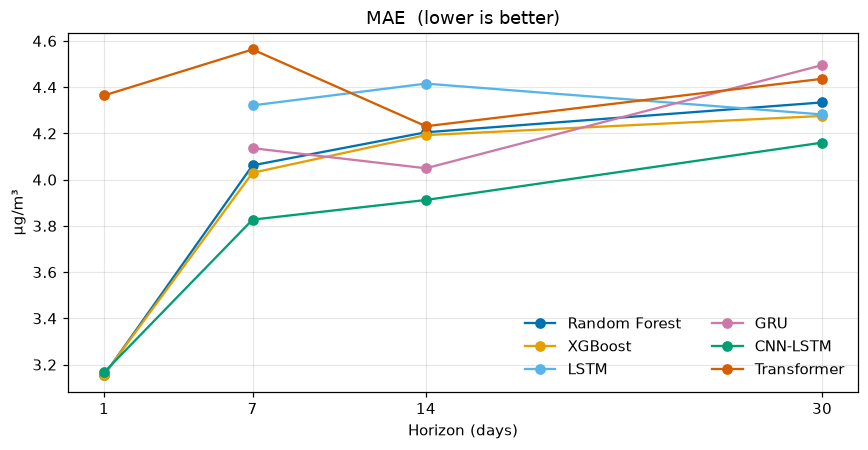

In [3]:
line_metric("MAE", "µg/m³", "lower is better")


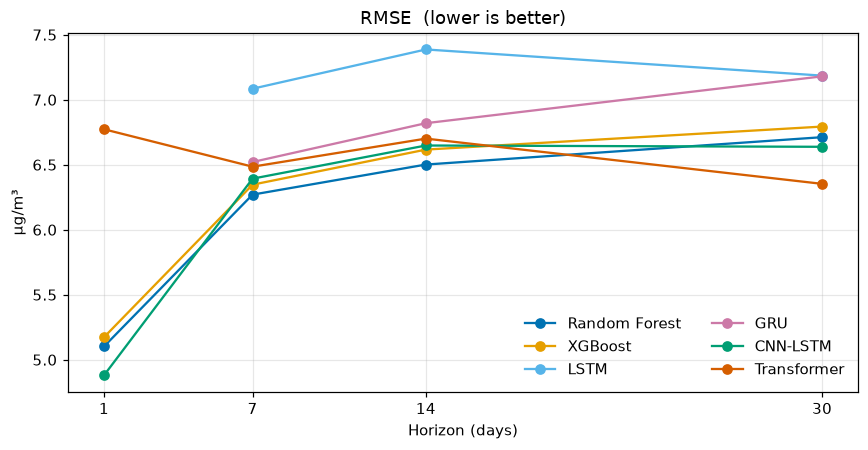

In [4]:
line_metric("RMSE", "µg/m³", "lower is better")


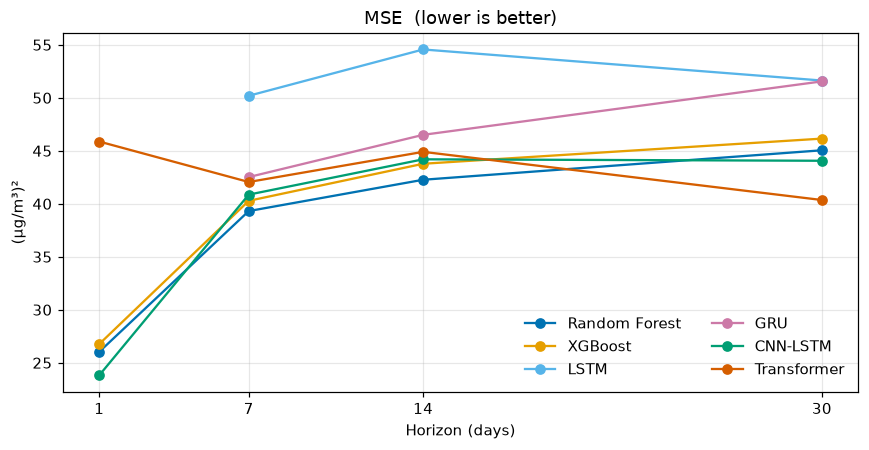

In [5]:
line_metric("MSE", "(µg/m³)²", "lower is better")


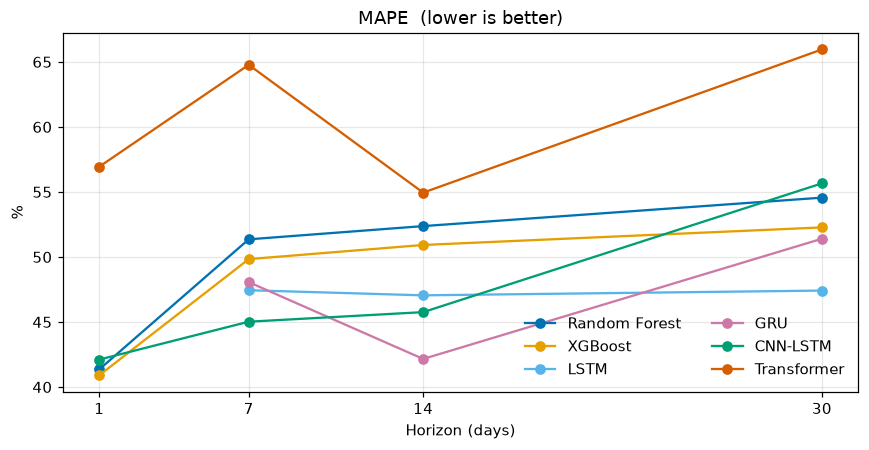

In [6]:
line_metric("MAPE", "%", "lower is better")


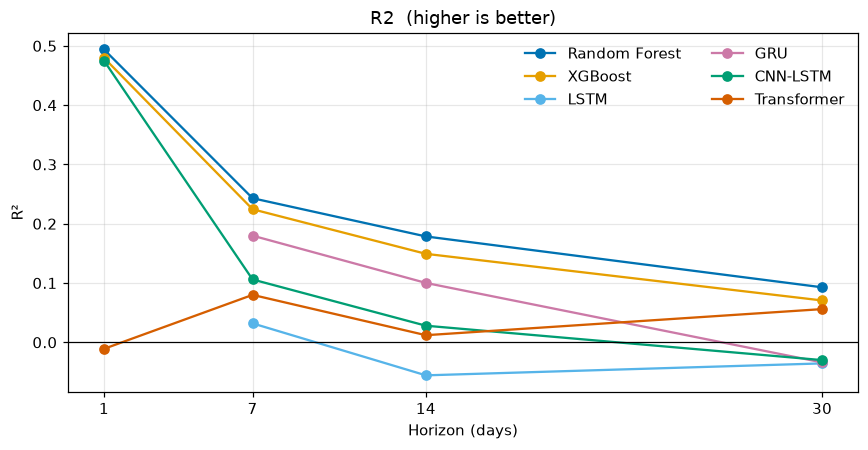

In [7]:
line_metric("R2", "R²", "higher is better", zero_line=True)


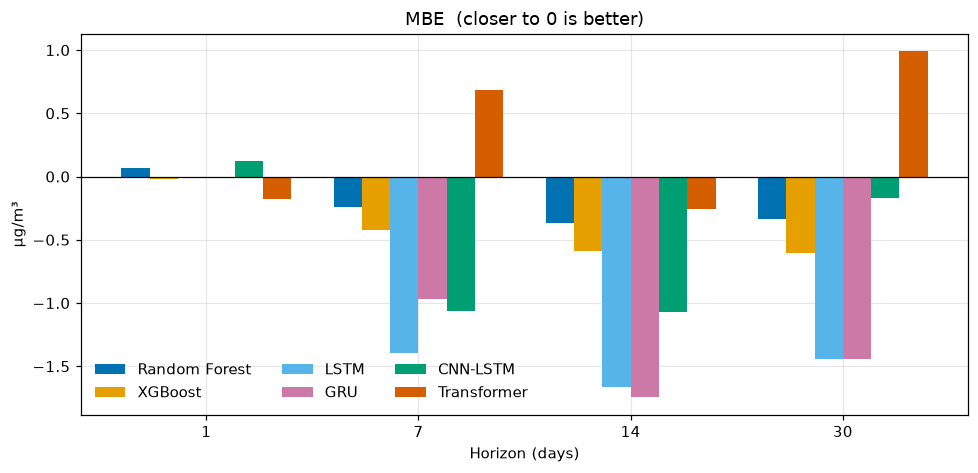

In [8]:
grouped_bars("MBE", "µg/m³", "closer to 0 is better", zero_line=True)


## Combinations

MAE grouped by horizon is the ranking chart. MAE vs RMSE shows when those two disagree, large misses versus many moderate errors. RMSE/MAE is a tail index. Gaussian noise sits near 1.25. Higher means a heavier tail. MAE vs R² pairs typical error with explained variance. MAE(H) / MAE(1) is only drawn for models that have a 1-day score.


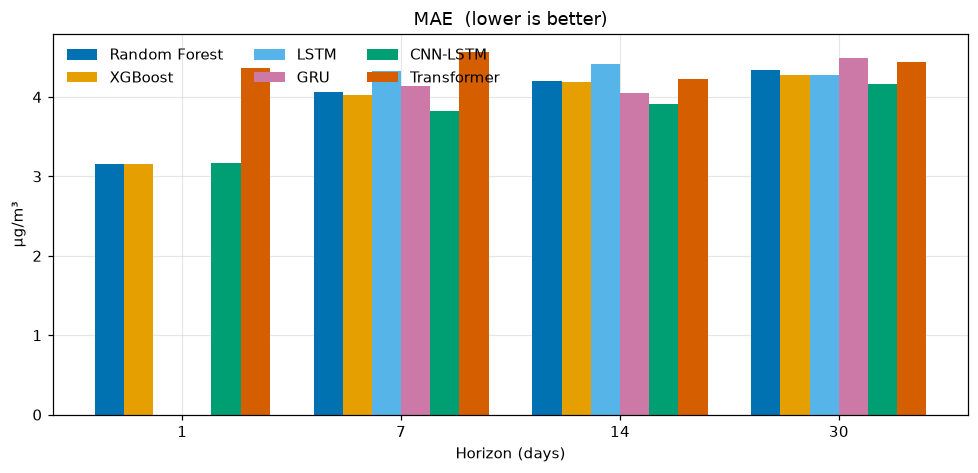

In [9]:
grouped_bars("MAE", "µg/m³", "lower is better")


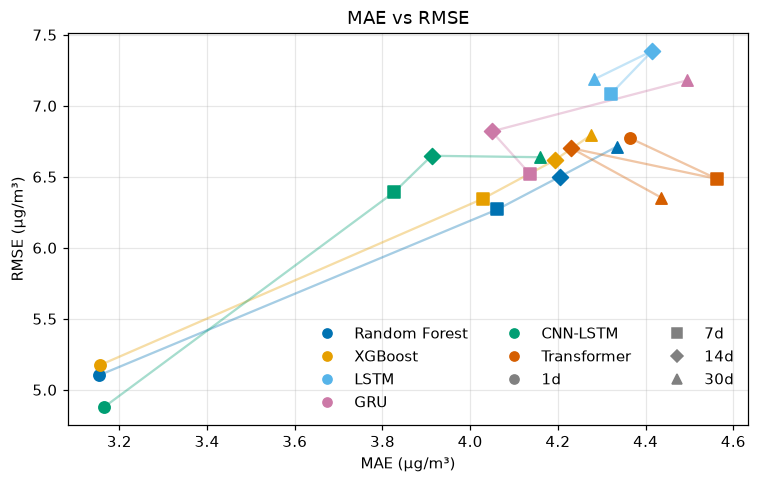

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for model in MODELS:
    sub = df[df["Model"] == model]
    ax.plot(sub["MAE"], sub["RMSE"], color=COLORS[model], alpha=0.35)
    for _, row in sub.iterrows():
        ax.scatter(
            row["MAE"],
            row["RMSE"],
            color=COLORS[model],
            marker=MARKERS[int(row["Horizon_Days"])],
            s=55,
            zorder=3,
        )
handles = [
    plt.Line2D([0], [0], color=COLORS[m], marker="o", linestyle="", label=m)
    for m in MODELS
] + [
    plt.Line2D([0], [0], color="grey", marker=mk, linestyle="", label=f"{h}d")
    for h, mk in MARKERS.items()
]
ax.set_xlabel("MAE (µg/m³)")
ax.set_ylabel("RMSE (µg/m³)")
ax.set_title("MAE vs RMSE")
ax.legend(handles=handles, frameon=False, ncol=3)
fig.tight_layout()
plt.show()


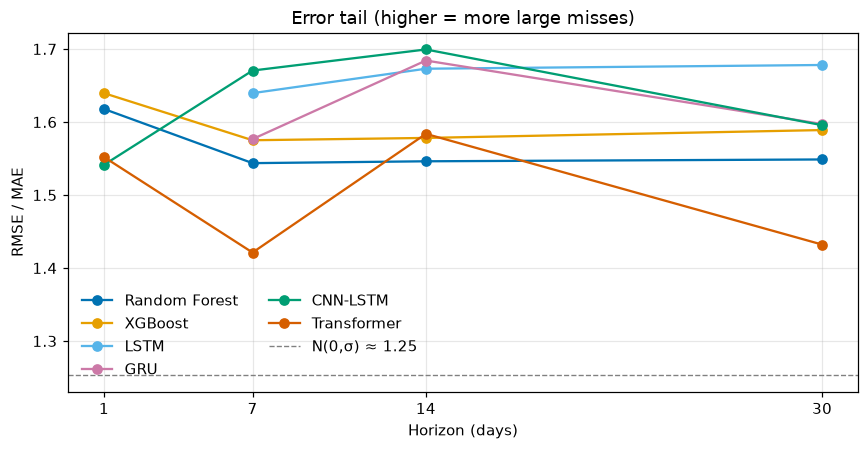

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in MODELS:
    mae = np.asarray(values(model, "MAE"), dtype=float)
    rmse = np.asarray(values(model, "RMSE"), dtype=float)
    ax.plot(HORIZONS, rmse / mae, marker="o", color=COLORS[model], label=model)
ax.axhline(1.253, color="grey", linestyle="--", linewidth=0.9, label="N(0,σ) ≈ 1.25")
ax.set_xticks(HORIZONS)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("RMSE / MAE")
ax.set_title("Error tail (higher = more large misses)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


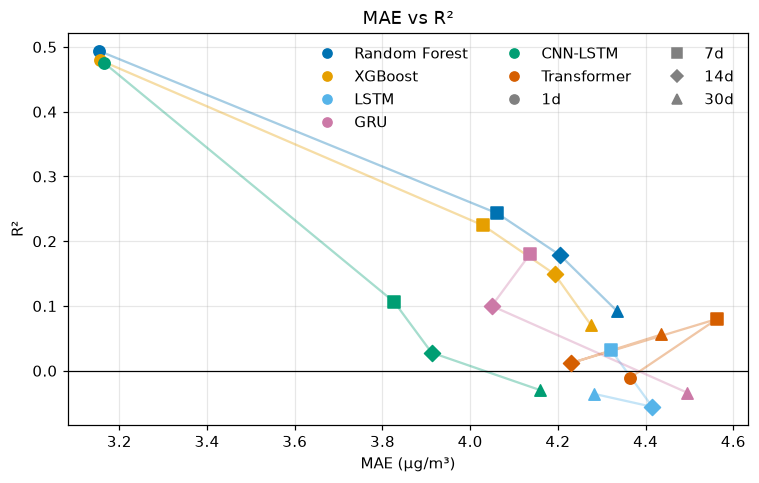

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for model in MODELS:
    sub = df[df["Model"] == model]
    ax.plot(sub["MAE"], sub["R2"], color=COLORS[model], alpha=0.35)
    for _, row in sub.iterrows():
        ax.scatter(
            row["MAE"],
            row["R2"],
            color=COLORS[model],
            marker=MARKERS[int(row["Horizon_Days"])],
            s=55,
            zorder=3,
        )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("MAE (µg/m³)")
ax.set_ylabel("R²")
ax.set_title("MAE vs R²")
handles = [
    plt.Line2D([0], [0], color=COLORS[m], marker="o", linestyle="", label=m)
    for m in MODELS
] + [
    plt.Line2D([0], [0], color="grey", marker=mk, linestyle="", label=f"{h}d")
    for h, mk in MARKERS.items()
]
ax.legend(handles=handles, frameon=False, ncol=3)
fig.tight_layout()
plt.show()


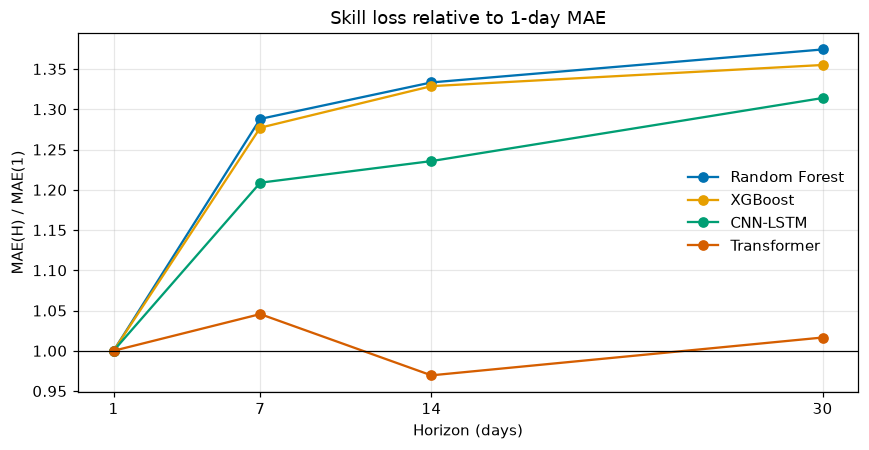

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in MODELS:
    mae = np.asarray(values(model, "MAE"), dtype=float)
    if np.isnan(mae[0]):
        continue
    ax.plot(HORIZONS, mae / mae[0], marker="o", color=COLORS[model], label=model)
ax.axhline(1, color="black", linewidth=0.8)
ax.set_xticks(HORIZONS)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("MAE(H) / MAE(1)")
ax.set_title("Skill loss relative to 1-day MAE")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


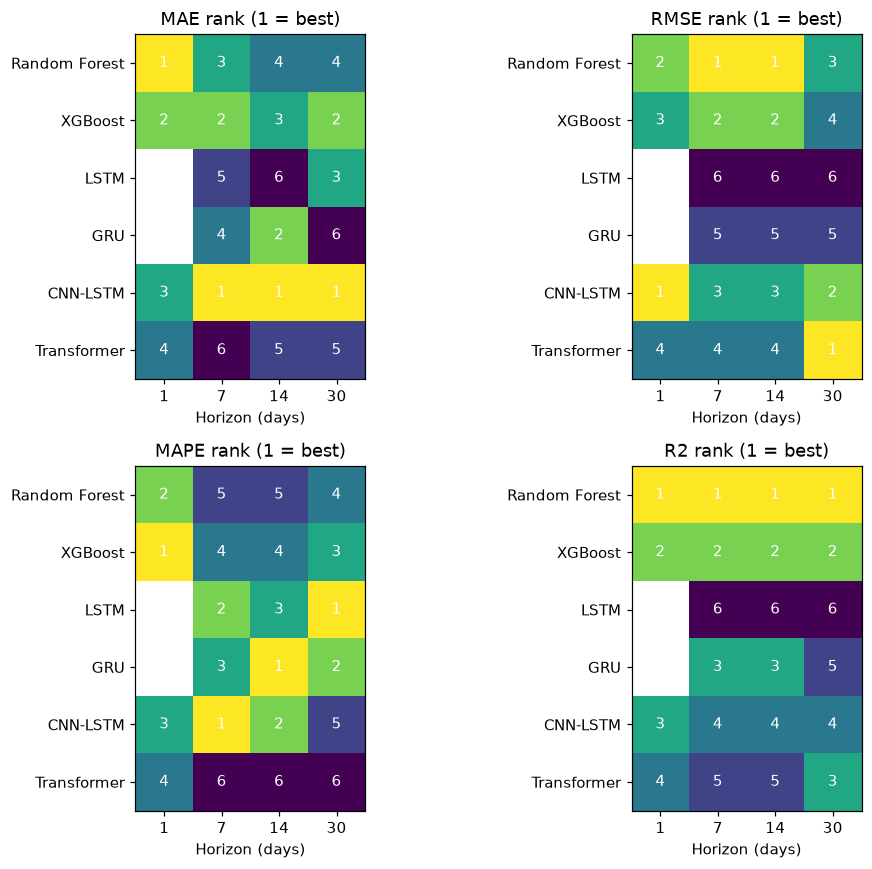

In [14]:
rank_metrics = {"MAE": True, "RMSE": True, "MAPE": True, "R2": False}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (col, low_is_best) in zip(axes.ravel(), rank_metrics.items()):
    table = df.pivot(index="Model", columns="Horizon_Days", values=col).reindex(
        index=MODELS, columns=HORIZONS
    )
    ranks = table.rank(axis=0, ascending=low_is_best, method="min")
    ax.imshow(
        np.ma.masked_invalid(ranks.to_numpy()),
        cmap="viridis_r",
        vmin=1,
        vmax=len(MODELS),
    )
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels(HORIZONS)
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS)
    ax.set_xlabel("Horizon (days)")
    ax.set_title(f"{col} rank (1 = best)")
    ax.grid(False)
    for i in range(len(MODELS)):
        for j in range(len(HORIZONS)):
            val = ranks.iloc[i, j]
            if pd.isna(val):
                continue
            ax.text(j, i, int(val), ha="center", va="center", color="white")
fig.tight_layout()
plt.show()
